In [ ]:
# Front Sprite till 809 (Gen 7)
# Back Sprite till 809 with 36 missing (First missing at 657: Frogadier)

In [71]:
import pandas as pd
import ast
from matplotlib import pyplot as plt

In [281]:
# First 7 Generations load in
df_pokemon = pd.read_csv('PokeAPI_output.csv')[0:809]
# Remove Pokemon 678
df_pokemon.drop(677, inplace=True)
df_pokemon.shape

(808, 9)

In [283]:
# Check for Nulls
df_pokemon.isna().sum()

id                 0
name               0
height             0
weight             0
types              0
abilities          0
base_stats         0
front_pic_link     0
back_pic_link     36
dtype: int64

In [285]:
# Convert types from str to object for processing
df_pokemon['types2'] = df_pokemon['types'].apply(ast.literal_eval)

# Verify that each pokemon are either mono or bi-types
list_lengths = df_pokemon['types2'].apply(len)

min_length = list_lengths.min()
max_length = list_lengths.max()

print(f"Smallest list size: {min_length}")
print(f"Largest list size: {max_length}")

Smallest list size: 1
Largest list size: 2


In [287]:
# Separate types into Primary and Secondary Typing
df_pokemon['type_pri'] = df_pokemon['types2'].apply(lambda x: x[0] if len(x) >= 1 else None)
df_pokemon['type_sec'] = df_pokemon['types2'].apply(lambda x: x[1] if len(x) == 2 else None)

Text(0.5, 1.0, 'Primary type')

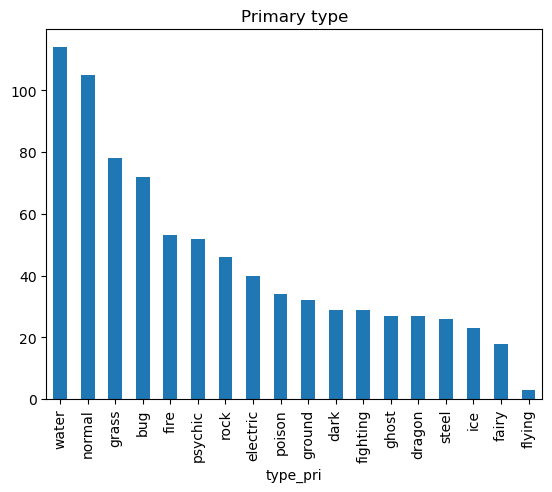

In [289]:
df_pokemon['type_pri'].value_counts().plot.bar()
plt.title('Primary type')

Text(0.5, 1.0, 'Secondary type')

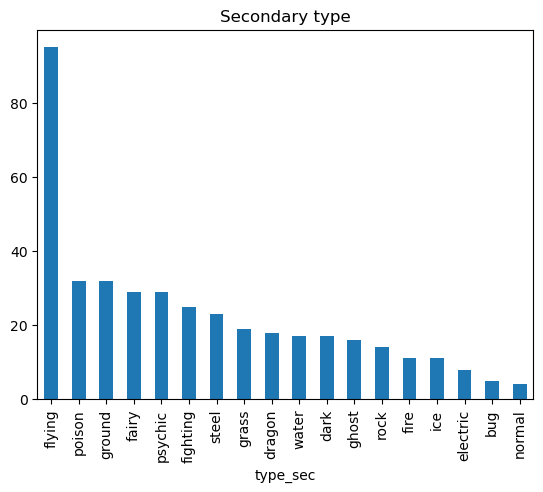

In [291]:
df_pokemon['type_sec'].value_counts().plot.bar()
plt.title('Secondary type')

In [299]:
df_types = df_pokemon
df_types = df_types[["id", "name", "type_pri", "type_sec"]]
df_types["image"] = df_types["name"]+"_front.png"
df_types

C:\Users\B_Ash\AppData\Local\Temp\ipykernel_15580\924073863.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_types["image"] = df_types["name"]+"_front.png"


,id,name,type_pri,type_sec,image
0,1,bulbasaur,grass,poison,bulbasaur_front.png
1,2,ivysaur,grass,poison,ivysaur_front.png
2,3,venusaur,grass,poison,venusaur_front.png
3,4,charmander,fire,None,charmander_front.png
4,5,charmeleon,fire,None,charmeleon_front.png
...,...,...,...,...,...
804,805,stakataka,rock,steel,stakataka_front.png
805,806,blacephalon,fire,ghost,blacephalon_front.png
806,807,zeraora,electric,None,zeraora_front.png
807,808,meltan,steel,None,meltan_front.png


In [303]:
# Df for supervised model
all_types = df_types["type_pri"].unique().tolist()
df_sup = df_types.copy()

# Start by creating zero-filled columns for each type
for t in all_types:
    df_sup[t] = 0.0

# Populate the type columns based on primary and secondary types
for idx, row in df_sup.iterrows():
    if row['type_sec'] is None:
        df_sup.at[idx, row['type_pri']] = 1.0
    else:
        df_sup.at[idx, row['type_pri']] = 0.5
        df_sup.at[idx, row['type_sec']] = 0.5

df_sup

,id,name,type_pri,type_sec,image,grass,fire,water,bug,normal,...,fairy,fighting,psychic,rock,ghost,ice,dragon,dark,steel,flying
0,1,bulbasaur,grass,poison,bulbasaur_front.png,0.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,ivysaur,grass,poison,ivysaur_front.png,0.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,venusaur,grass,poison,venusaur_front.png,0.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,charmander,fire,None,charmander_front.png,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,charmeleon,fire,None,charmeleon_front.png,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804,805,stakataka,rock,steel,stakataka_front.png,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.5,0.0
805,806,blacephalon,fire,ghost,blacephalon_front.png,0.0,0.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
806,807,zeraora,electric,None,zeraora_front.png,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
807,808,meltan,steel,None,meltan_front.png,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [217]:
# Creates the Feature Matrix from our images

from torchvision import models, transforms
from PIL import Image
import torch
import os
from tqdm import tqdm
import numpy as np

# Load pretrained model
resnet = models.resnet50(pretrained=True)
resnet.eval()  # Inference mode
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])  # Remove final classification layer

# Preprocessing transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def extract_features(img_path):
    image = Image.open(img_path).convert('RGB')
    img_t = transform(image).unsqueeze(0)
    with torch.no_grad():
        features = feature_extractor(img_t)
    return features.squeeze().numpy()

# Extract features for all Pokémon
image_dir = 'C:/Users/B_Ash/Downloads/GA Tech/ISYE 6740/Main/ISYE6740_Project/Pokemon_Images/Front'
features = []
ids = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    poke_id = row['name']
    file_name = f"{poke_id}_front.png"  # or match on 'name' if filenames use names
    file_path = os.path.join(image_dir, file_name)
    if os.path.exists(file_path):
        f = extract_features(file_path)
        features.append(f)
        ids.append(poke_id)

import numpy as np
features_matrix = np.vstack(features)

C:\Users\B_Ash\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\B_Ash\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
 80%|████████  | 649/809 [01:59<00:30,  5.17it/s]C:\Users\B_Ash\anaconda3\Lib\site-packages\PIL\Image.py:981: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 809/809 [02:29<00:00,  5.42it/s]


In [ ]:
##### Unsupervised Part #####

In [305]:
df_types2 = df_types.copy()

In [239]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=18, random_state=42)
kmeans_labels = kmeans.fit_predict(features_matrix)

df_types2['kmeans_cluster'] = kmeans_labels

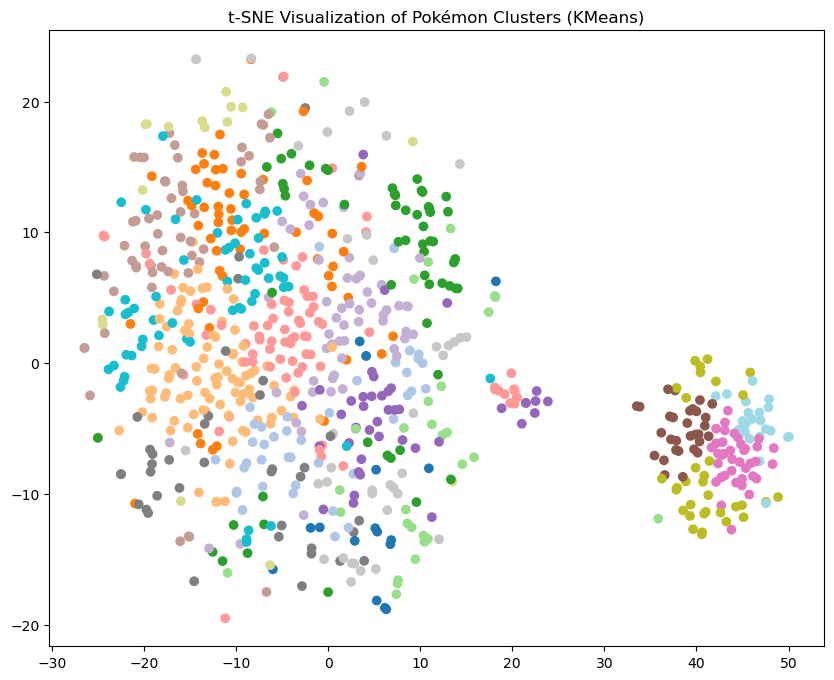

In [251]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(features_matrix)

plt.figure(figsize=(10, 8))
plt.scatter(reduced[:, 0], reduced[:, 1], c=kmeans_labels, cmap='tab20')
plt.title("t-SNE Visualization of Pokémon Clusters (KMeans)")
plt.show()

In [249]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(features_matrix)

db = DBSCAN(eps=1.5, min_samples=5).fit(X_scaled)
df_types2['dbscan_cluster'] = db.labels_

In [263]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

# K-Means (you can adjust n_clusters)
kmeans = KMeans(n_clusters=18, random_state=42)
kmeans_labels = kmeans.fit_predict(features_matrix)
df_types2['kmeans_cluster'] = kmeans_labels

# DBSCAN
db = DBSCAN(eps=5, min_samples=5)
db_labels = db.fit_predict(features_matrix)
df_types2['dbscan_cluster'] = db_labels

# GMM
gmm = GaussianMixture(n_components=18, random_state=42)
gmm_labels = gmm.fit_predict(features_matrix)
df_types2['gmm_cluster'] = gmm_labels

In [264]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(features_matrix)

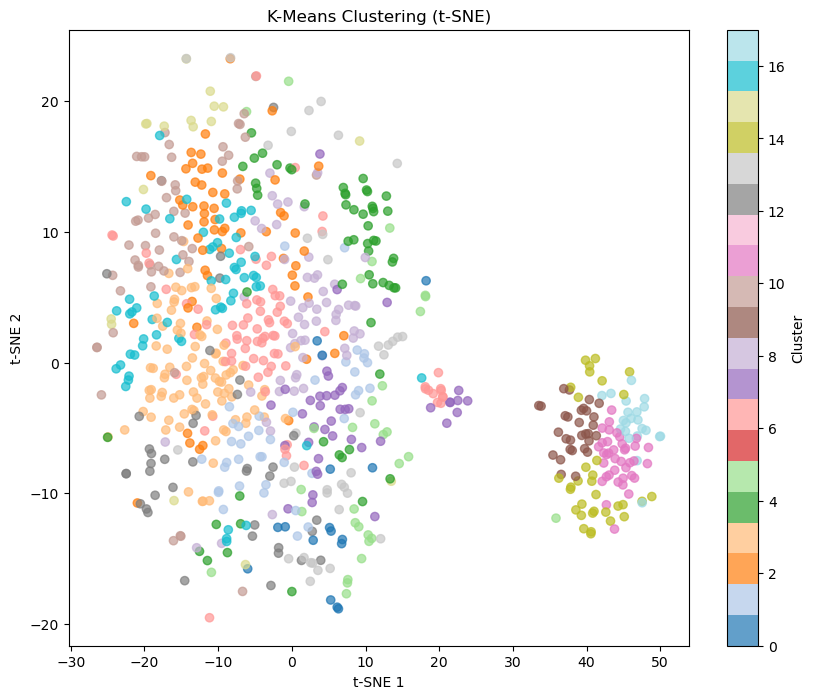

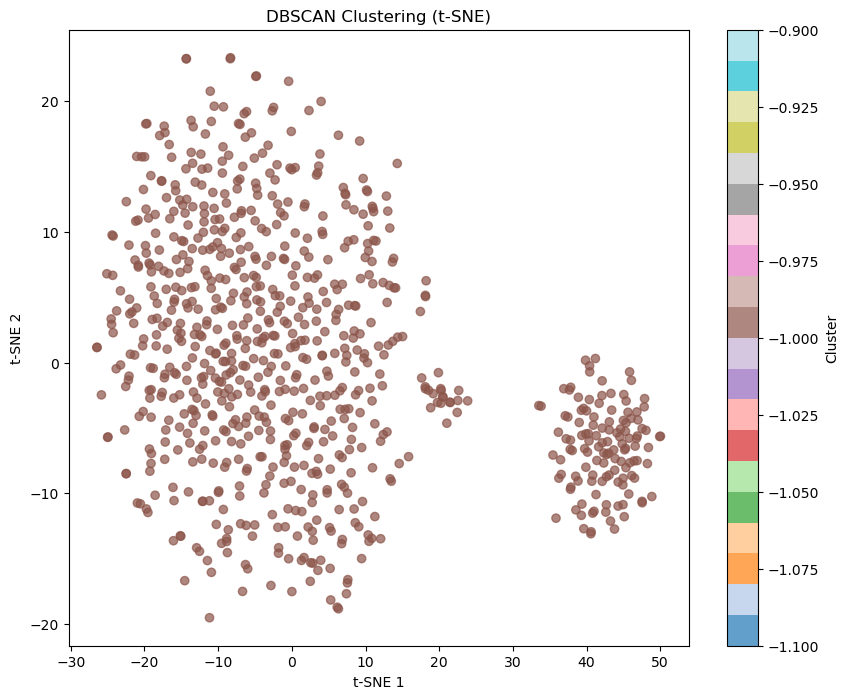

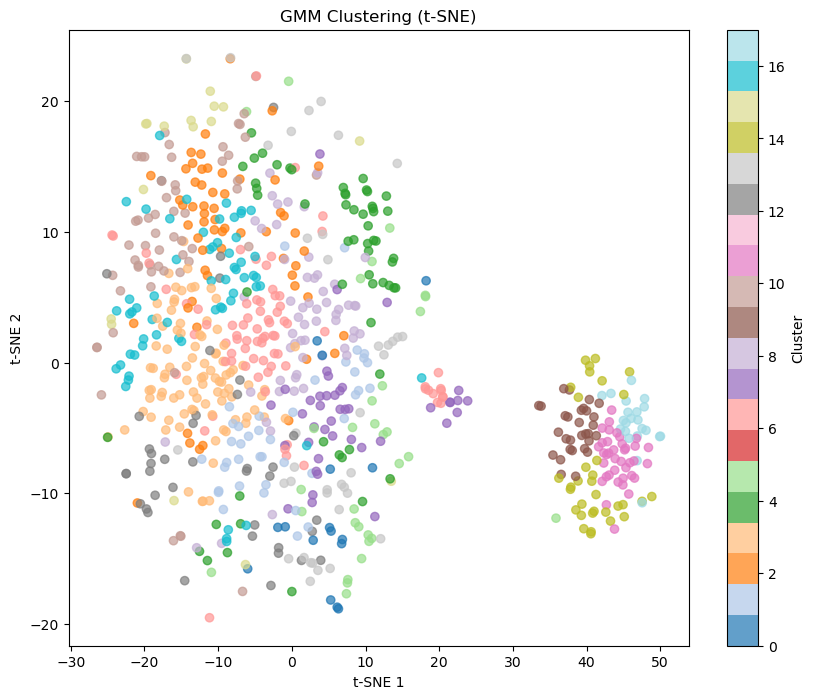

In [269]:
import matplotlib.pyplot as plt

def plot_clusters(X_2d, labels, title):
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab20', alpha=0.7)
    plt.title(title)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.colorbar(scatter, label='Cluster')
    plt.show()

plot_clusters(X_tsne, kmeans_labels, "K-Means Clustering (t-SNE)")
plot_clusters(X_tsne, db_labels, "DBSCAN Clustering (t-SNE)")
plot_clusters(X_tsne, gmm_labels, "GMM Clustering (t-SNE)")

In [273]:
df_types2['kmeans_cluster'] = kmeans_labels
df_types2['dbscan_cluster'] = db_labels
df_types2['gmm_cluster'] = gmm_labels

In [275]:
df_types2

,id,name,type_pri,type_sec,image,kmeans_cluster,dbscan_cluster,gmm_cluster
0,1,bulbasaur,grass,poison,bulbasaur_front.png,16,-1,16
1,2,ivysaur,grass,poison,ivysaur_front.png,12,-1,12
2,3,venusaur,grass,poison,venusaur_front.png,1,-1,1
3,4,charmander,fire,None,charmander_front.png,2,-1,2
4,5,charmeleon,fire,None,charmeleon_front.png,2,-1,2
...,...,...,...,...,...,...,...,...
804,805,stakataka,rock,steel,stakataka_front.png,14,-1,14
805,806,blacephalon,fire,ghost,blacephalon_front.png,7,-1,7
806,807,zeraora,electric,None,zeraora_front.png,9,-1,9
807,808,meltan,steel,None,meltan_front.png,6,-1,6


In [277]:
df_types2['dbscan_cluster'].unique()

array([-1], dtype=int64)